# 03 - Compound ↔ Disease Drug-Repositioning Subgraph

**Coverage**: Step 7 (Drug-repositioning deep-dive) · Step 8 (Metapath enumeration + DWPC) · Step 9 (Open-world assumption & negative-sampling design)

**Goal**: Quantify CtD/CpD sparsity, enumerate all length-2 metapaths between Compound and Disease, implement DWPC as the canonical feature baseline, and design a principled negative-sampling strategy.

In [1]:
from utils import load_hetnet, setup_plot_style
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict

setup_plot_style()

In [2]:
hetnet = load_hetnet()

# Extract Compound and Disease nodes
compounds = [n for n in hetnet['nodes'] if n['kind'] == 'Compound']
diseases  = [n for n in hetnet['nodes'] if n['kind'] == 'Disease']
print(f'Compounds: {len(compounds):,}')
print(f'Diseases:  {len(diseases):,}')
print(f'Max possible Compound-Disease pairs: {len(compounds) * len(diseases):,}')

Compounds: 1,552
Diseases:  137
Max possible Compound-Disease pairs: 212,624


In [3]:
# All direct Compound-Disease edges (CtD and CpD)
cd_edges = [
    e for e in hetnet['edges']
    if (e['source_id'][0] == 'Compound' and e['target_id'][0] == 'Disease')
    or (e['source_id'][0] == 'Disease' and e['target_id'][0] == 'Compound')
]

from collections import Counter
kind_counts = Counter(e['kind'] for e in cd_edges)
print('Compound ↔ Disease edge type counts:')
for k, v in kind_counts.most_common():
    print(f'  {k:8s}: {v:,}')

n_ctd = kind_counts.get('treats', 0)
n_cpd = kind_counts.get('palliates', 0)
max_pairs = len(compounds) * len(diseases)
print(f'\nCtD density = {n_ctd} / ({len(compounds)} × {len(diseases)}) = {n_ctd/max_pairs:.4%}')
print(f'CpD density = {n_cpd} / ({len(compounds)} × {len(diseases)}) = {n_cpd/max_pairs:.4%}')

Compound ↔ Disease edge type counts:
  treats  : 755
  palliates: 390

CtD density = 755 / (1552 × 137) = 0.3551%
CpD density = 390 / (1552 × 137) = 0.1834%


In [4]:
# Per-node CtD degree (participation stats)
compound_treats = defaultdict(set)
disease_treated_by = defaultdict(set)

for e in cd_edges:
    if e['kind'] != 'treats':
        continue
    # 'treats' edges are directed Compound → Disease
    if e['source_id'][0] == 'Compound':
        c, d = e['source_id'][1], e['target_id'][1]
    else:
        c, d = e['target_id'][1], e['source_id'][1]
    compound_treats[c].add(d)
    disease_treated_by[d].add(c)

active_compounds = len(compound_treats)
active_diseases  = len(disease_treated_by)
print(f'Compounds in CtD: {active_compounds} / {len(compounds)} ({active_compounds/len(compounds):.1%})')
print(f'Diseases  in CtD: {active_diseases}  / {len(diseases)}  ({active_diseases/len(diseases):.1%})')

avg_ctd_per_compound = np.mean([len(s) for s in compound_treats.values()])
avg_ctd_per_disease  = np.mean([len(s) for s in disease_treated_by.values()])
print(f'\nMean diseases treated per active compound : {avg_ctd_per_compound:.2f}')
print(f'Mean compounds per active disease          : {avg_ctd_per_disease:.2f}')

Compounds in CtD: 387 / 1552 (24.9%)
Diseases  in CtD: 77  / 137  (56.2%)

Mean diseases treated per active compound : 1.95
Mean compounds per active disease          : 9.81


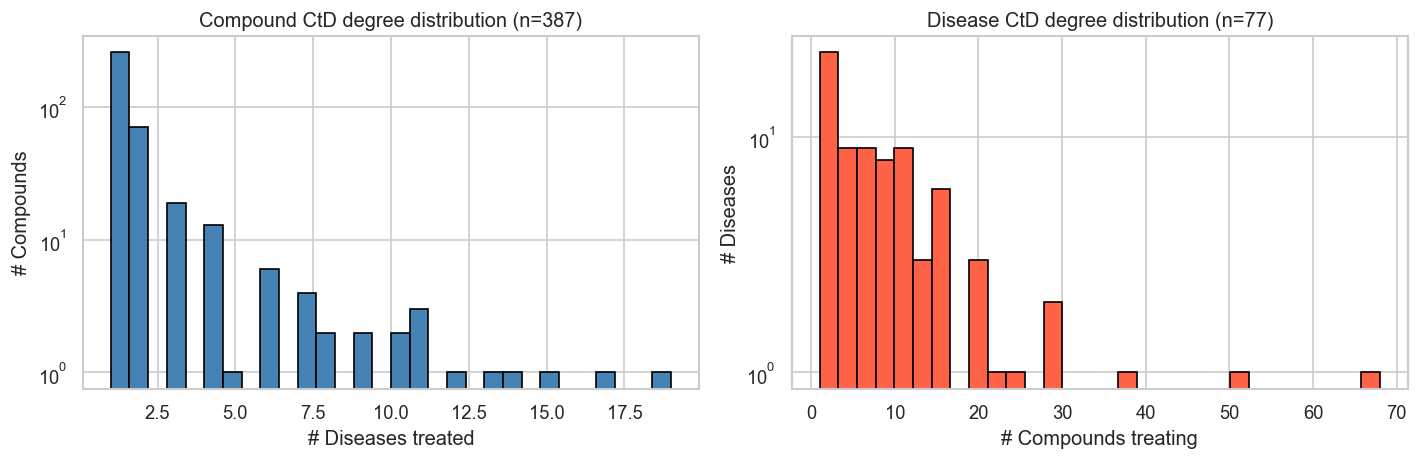

In [5]:
# CtD degree histograms (active nodes only)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist([len(s) for s in compound_treats.values()], bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('# Diseases treated')
axes[0].set_ylabel('# Compounds')
axes[0].set_title(f'Compound CtD degree distribution (n={active_compounds})')
axes[0].set_yscale('log')

axes[1].hist([len(s) for s in disease_treated_by.values()], bins=30, color='tomato', edgecolor='black')
axes[1].set_xlabel('# Compounds treating')
axes[1].set_ylabel('# Diseases')
axes[1].set_title(f'Disease CtD degree distribution (n={active_diseases})')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [6]:
# Top-10 most-treated diseases (highest repositioning potential)
name_lookup = {(n['kind'], n['identifier']): n['name'] for n in hetnet['nodes']}

top_diseases = sorted(disease_treated_by.items(), key=lambda x: -len(x[1]))[:10]
print('=== Top-10 Diseases by compound count ===')
for d_id, comps in top_diseases:
    name = name_lookup.get(('Disease', d_id), d_id)
    print(f'  {len(comps):3d}  {name}')

print('\n=== Top-10 broad-spectrum compounds ===')
top_compounds = sorted(compound_treats.items(), key=lambda x: -len(x[1]))[:10]
for c_id, dis in top_compounds:
    name = name_lookup.get(('Compound', c_id), c_id)
    print(f'  {len(dis):3d}  {name}')

=== Top-10 Diseases by compound count ===
   68  hypertension
   51  hematologic cancer
   37  asthma
   29  breast cancer
   28  coronary artery disease
   25  epilepsy syndrome
   22  type 2 diabetes mellitus
   21  prostate cancer
   21  glaucoma
   21  psoriasis

=== Top-10 broad-spectrum compounds ===
   19  Methotrexate
   17  Doxorubicin
   15  Prednisone
   14  Epirubicin
   13  Prednisolone
   12  Triamcinolone
   11  Etoposide
   11  Betamethasone
   11  Dexamethasone
   10  Methylprednisolone


## Bipartite Visualization — Top Hub Subgraph

Full graph is too dense to visualise; we render the top-hub subgraph to reveal cluster structure.

Bipartite subgraph: 30 nodes, 59 edges


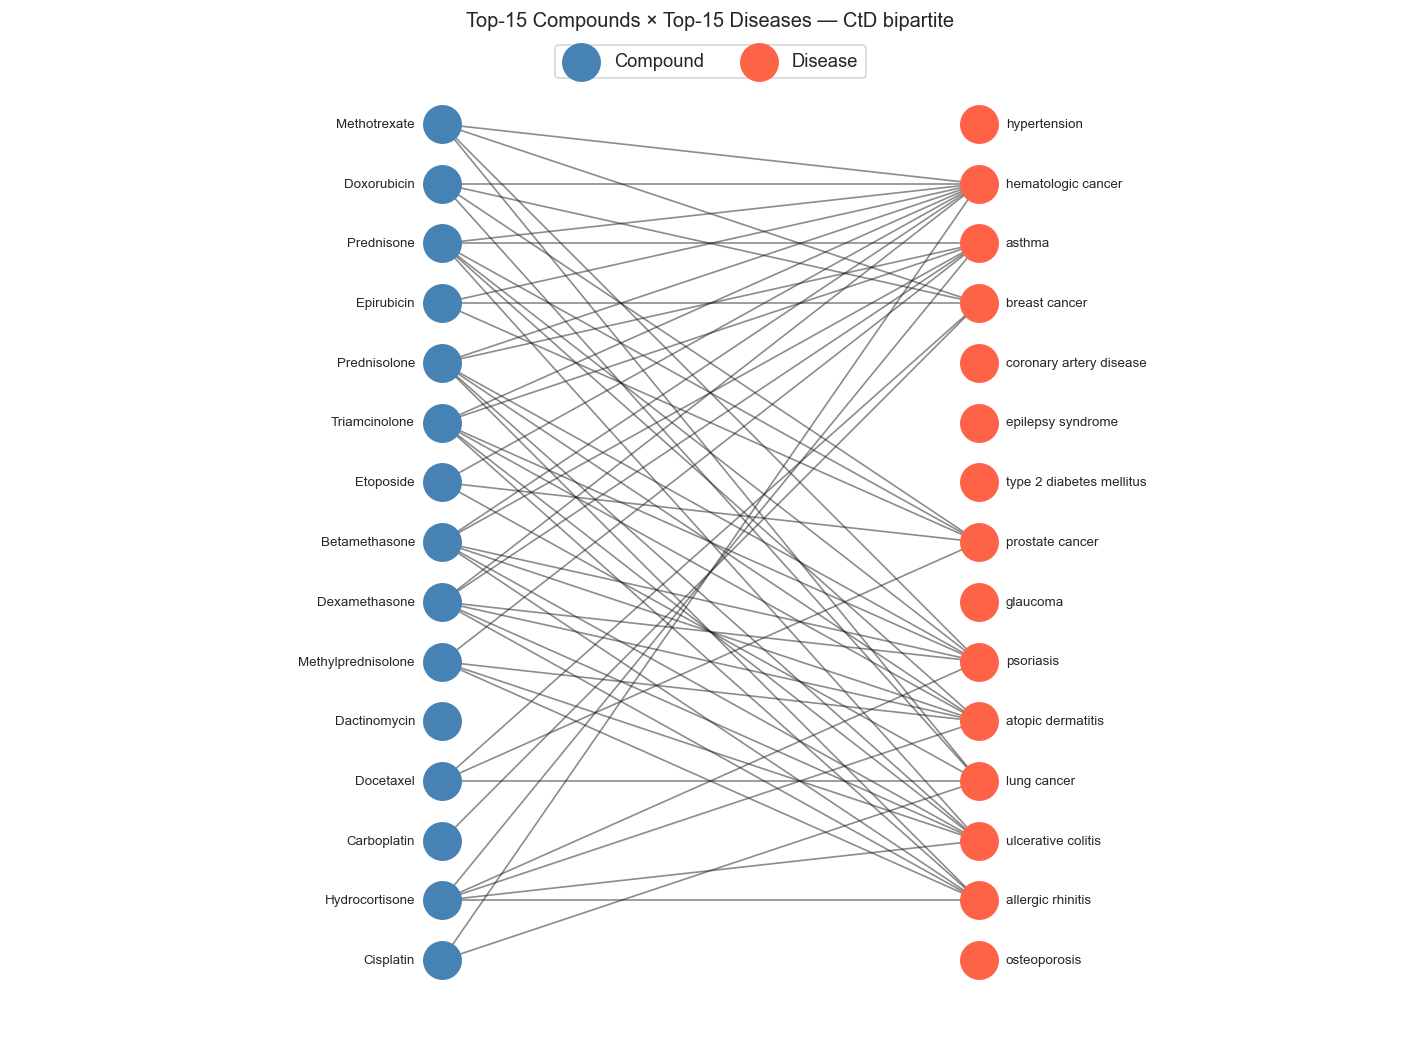

In [7]:
# Draw bipartite subgraph: top-15 Compounds × top-15 Diseases
TOP_N = 15
top_c_ids = [c for c, _ in sorted(compound_treats.items(), key=lambda x: -len(x[1]))[:TOP_N]]
top_d_ids = [d for d, _ in sorted(disease_treated_by.items(), key=lambda x: -len(x[1]))[:TOP_N]]

B = nx.Graph()
for c in top_c_ids:
    B.add_node(('Compound', c), bipartite=0, name=name_lookup.get(('Compound', c), c))
for d in top_d_ids:
    B.add_node(('Disease', d), bipartite=1, name=name_lookup.get(('Disease', d), d))

for c in top_c_ids:
    for d in compound_treats[c]:
        if d in top_d_ids:
            B.add_edge(('Compound', c), ('Disease', d))

print(f'Bipartite subgraph: {B.number_of_nodes()} nodes, {B.number_of_edges()} edges')

pos = {}
for i, c in enumerate(top_c_ids):
    pos[('Compound', c)] = (0, -i)
for i, d in enumerate(top_d_ids):
    pos[('Disease', d)] = (1, -i)

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_nodes(B, pos, nodelist=[n for n in B if n[0] == 'Compound'],
                       node_color='steelblue', node_size=500, ax=ax, label='Compound')
nx.draw_networkx_nodes(B, pos, nodelist=[n for n in B if n[0] == 'Disease'],
                       node_color='tomato', node_size=500, ax=ax, label='Disease')
nx.draw_networkx_edges(B, pos, alpha=0.5, ax=ax)

labels = {n: B.nodes[n]['name'][:25] for n in B}
label_pos = {k: (v[0] + (-0.05 if k[0] == 'Compound' else 0.05), v[1]) for k, v in pos.items()}
for n, (x, y) in label_pos.items():
    ha = 'right' if n[0] == 'Compound' else 'left'
    ax.text(x, y, labels[n], ha=ha, va='center', fontsize=8)

ax.set_xlim(-0.8, 1.8)
ax.set_title(f'Top-{TOP_N} Compounds × Top-{TOP_N} Diseases — CtD bipartite')
ax.axis('off')
ax.legend(loc='upper center', ncol=2)
plt.tight_layout()
plt.show()

## Step 7 · Two-hop Metapath Coverage: CbG–GaD

Direct CtD edges are sparse (0.36%). Compound → Gene → Disease paths cast a much wider net and are the strongest single-metapath baseline (Himmelstein et al. 2017). We quantify coverage and CtD recall before the systematic enumeration.

In [8]:
# Collect Compound–Gene (CbG: binds) and Gene–Disease (GaD: associates) edges
cg_edges = defaultdict(set)  # compound → {gene}
gd_edges = defaultdict(set)  # gene     → {disease}

for e in hetnet['edges']:
    s_kind, t_kind = e['source_id'][0], e['target_id'][0]
    s_id, t_id = e['source_id'][1], e['target_id'][1]
    if e['kind'] == 'binds' and {s_kind, t_kind} == {'Compound', 'Gene'}:
        c, g = (s_id, t_id) if s_kind == 'Compound' else (t_id, s_id)
        cg_edges[c].add(g)
    elif e['kind'] == 'associates' and {s_kind, t_kind} == {'Gene', 'Disease'}:
        g, d = (s_id, t_id) if s_kind == 'Gene' else (t_id, s_id)
        gd_edges[g].add(d)

print(f'CbG edges : {sum(len(v) for v in cg_edges.values()):,}  ({len(cg_edges)} active Compounds)')
print(f'GaD edges : {sum(len(v) for v in gd_edges.values()):,}  ({len(gd_edges)} active Genes)')

# Count CbG-GaD paths per (Compound, Disease) pair
from collections import Counter
path_counter = Counter()
for c, genes in cg_edges.items():
    for g in genes:
        for d in gd_edges.get(g, ()):
            path_counter[(c, d)] += 1

reachable_pairs = len(path_counter)
print(f'\nReachable (C,D) pairs via CbG-GaD : {reachable_pairs:,} / {max_pairs:,} ({reachable_pairs/max_pairs:.2%})')
print(f'Coverage lift over direct CtD       : {reachable_pairs / n_ctd:.1f}×')

CbG edges : 11,571  (1389 active Compounds)
GaD edges : 12,623  (5392 active Genes)

Reachable (C,D) pairs via CbG-GaD : 27,498 / 212,624 (12.93%)
Coverage lift over direct CtD       : 36.4×


Known CtD pairs covered by CbG-GaD: 464 / 755 (61.5%)


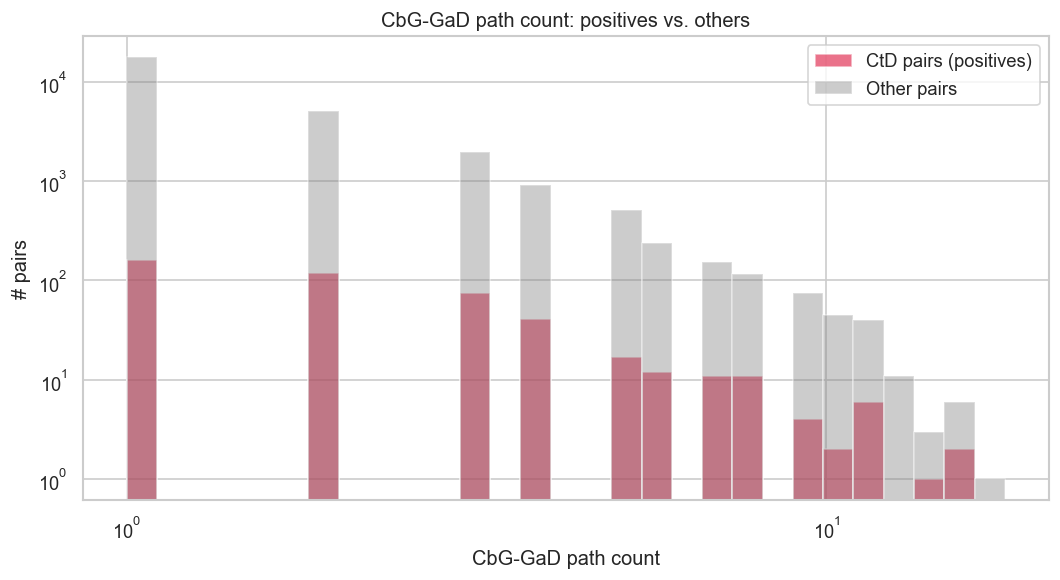

In [9]:
# Fraction of known CtD pairs reachable via CbG-GaD
ctd_pairs = {(c, d) for c, ds in compound_treats.items() for d in ds}
covered = sum(1 for pair in ctd_pairs if pair in path_counter)
print(f'Known CtD pairs covered by CbG-GaD: {covered} / {len(ctd_pairs)} ({covered/len(ctd_pairs):.1%})')

# Path-count distribution
path_counts_ctd   = [path_counter.get(p, 0) for p in ctd_pairs]
path_counts_other = [v for p, v in path_counter.items() if p not in ctd_pairs]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.logspace(0, np.log10(max(max(path_counts_ctd), max(path_counts_other)) + 1), 30)
ax.hist([c for c in path_counts_ctd if c > 0], bins=bins, alpha=0.6, label='CtD pairs (positives)', color='crimson')
ax.hist([c for c in path_counts_other if c > 0], bins=bins, alpha=0.4, label='Other pairs', color='gray')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('CbG-GaD path count')
ax.set_ylabel('# pairs')
ax.set_title('CbG-GaD path count: positives vs. others')
ax.legend()
plt.tight_layout()
plt.show()

## Summary So Far

| Metric | Value |
| --- | --- |
| Compounds | 1,552 |
| Diseases | 137 |
| CtD edges | 755 (density 0.36%) |
| CpD edges | 390 (density 0.18%) |
| CbG-GaD reachable pairs | 27,498 (12.9%, 36× lift) |

The following steps upgrade this baseline: systematic metapath enumeration, DWPC scoring, and principled negative-sampling design.

---

## Step 8 · Systematic Length-2 Metapath Enumeration

We enumerate **all** length-2 paths Compound → X → Disease over the full Hetionet schema, then rank by (a) coverage over all C-D pairs and (b) recall over known CtD positives.

This drives feature selection: metapaths with high CtD recall but low overall coverage are the most discriminative candidates.

In [10]:
from collections import defaultdict

# Build bidirectional edge index: (source_kind, edge_kind, target_kind) -> {source_id -> set(target_ids)}
edge_index = defaultdict(lambda: defaultdict(set))
for e in hetnet['edges']:
    sk, si = e['source_id']
    tk, ti = e['target_id']
    k = e['kind']
    edge_index[(sk, k, tk)][si].add(ti)
    edge_index[(tk, k, sk)][ti].add(si)  # bidirectional

compound_ids = set(n['identifier'] for n in hetnet['nodes'] if n['kind'] == 'Compound')
disease_ids  = set(n['identifier'] for n in hetnet['nodes'] if n['kind'] == 'Disease')

# Enumerate length-2 metapaths: Compound -e1-> X -e2-> Disease
compound_out = [(sk, k, tk) for (sk, k, tk) in edge_index if sk == 'Compound']
disease_in   = [(sk, k, tk) for (sk, k, tk) in edge_index if tk == 'Disease']

ctd_pairs = frozenset((c, d) for c, ds in compound_treats.items() for d in ds)

rows = []
mp_keys = {}  # metapath name -> (e1_key, e2_key) for DWPC reuse

for e1 in compound_out:
    for e2 in disease_in:
        if e1[2] != e2[0]:  # intermediate node type must match
            continue
        pair_hits = set()
        for c, xs in edge_index[e1].items():
            if c not in compound_ids:
                continue
            for x in xs:
                for d in edge_index[e2].get(x, ()):
                    if d in disease_ids:
                        pair_hits.add((c, d))
        if not pair_hits:
            continue
        mp_name = f"C\u2013{e1[1]}\u2013{e1[2][0]}\u2013{e2[1]}\u2013D"
        ctd_recall = sum(1 for p in ctd_pairs if p in pair_hits) / len(ctd_pairs)
        rows.append({
            'metapath':      mp_name,
            'via':           e1[2],
            'n_pairs':       len(pair_hits),
            'coverage_%':    round(100 * len(pair_hits) / max_pairs, 3),
            'ctd_recall_%':  round(100 * ctd_recall, 2),
        })
        mp_keys[mp_name] = (e1, e2)

mp_df = pd.DataFrame(rows).sort_values('ctd_recall_%', ascending=False).reset_index(drop=True)
print(f'{len(mp_df)} length-2 metapaths found')
mp_df

13 length-2 metapaths found


,metapath,via,n_pairs,coverage_%,ctd_recall_%
0,C–binds–G–associates–D,Gene,27498,12.933,61.46
1,C–resembles–C–treats–D,Compound,2927,1.377,51.79
2,C–treats–D–resembles–D,Disease,3602,1.694,44.77
3,C–upregulates–G–associates–D,Gene,13814,6.497,36.29
4,C–downregulates–G–associates–D,Gene,11566,5.440,33.91
5,C–downregulates–G–upregulates–D,Gene,6126,2.881,17.09
6,C–upregulates–G–upregulates–D,Gene,5586,2.627,16.16
7,C–upregulates–G–downregulates–D,Gene,5022,2.362,15.10
8,C–downregulates–G–downregulates–D,Gene,5224,2.457,15.10
9,C–binds–G–upregulates–D,Gene,3601,1.694,7.42


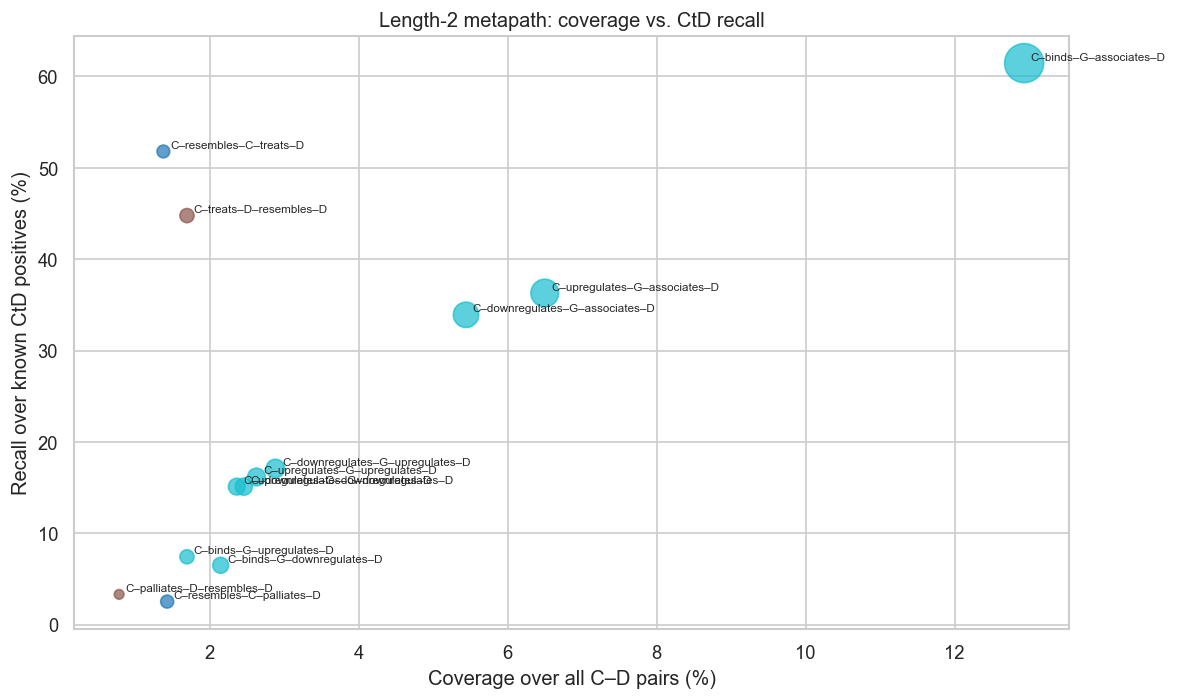

In [11]:
# Visualise: coverage vs. CtD recall, sized by n_pairs
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    mp_df['coverage_%'], mp_df['ctd_recall_%'],
    s=mp_df['n_pairs'] / 50, alpha=0.7,
    c=mp_df['via'].astype('category').cat.codes, cmap='tab10'
)
for _, row in mp_df.iterrows():
    ax.annotate(row['metapath'], (row['coverage_%'], row['ctd_recall_%']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Coverage over all C–D pairs (%)')
ax.set_ylabel('Recall over known CtD positives (%)')
ax.set_title('Length-2 metapath: coverage vs. CtD recall')
plt.tight_layout()
plt.show()

### DWPC — Degree-Weighted Path Count

Raw path count inflates scores for pairs passing through high-degree hubs (e.g. UBC). DWPC down-weights each traversal by the degree of the nodes visited:

$$\text{DWPC}(c, d \mid P) = \sum_{\text{walks}} \prod_{\text{edge }(u,v)} \frac{1}{\deg_P(u)^{\alpha} \cdot \deg_P(v)^{\alpha}}$$

with damping exponent $\alpha = 0.4$ (Himmelstein et al. 2017).

In [12]:
def dwpc_length2(e1_key, e2_key, compound_ids, disease_ids, alpha=0.4):
    """DWPC for a length-2 metapath. Returns {(compound_id, disease_id): score}."""
    src2int = edge_index[e1_key]   # compound -> set(intermediates)
    int2tgt = edge_index[e2_key]   # intermediate -> set(diseases)

    # Degree of each node under its respective edge type
    deg_e1_src = {n: len(s) for n, s in src2int.items()}
    deg_e1_int = defaultdict(int)
    for s, ts in src2int.items():
        for t in ts:
            deg_e1_int[t] += 1
    deg_e2_int = {n: len(s) for n, s in int2tgt.items()}
    deg_e2_tgt = defaultdict(int)
    for s, ts in int2tgt.items():
        for t in ts:
            deg_e2_tgt[t] += 1

    scores = defaultdict(float)
    for c, intermediates in src2int.items():
        if c not in compound_ids:
            continue
        dc = max(deg_e1_src.get(c, 1), 1)
        for x in intermediates:
            dx1 = max(deg_e1_int.get(x, 1), 1)
            dx2 = max(deg_e2_int.get(x, 1), 1)
            w1  = 1.0 / (dc ** alpha * dx1 ** alpha)
            for d in int2tgt.get(x, ()):
                if d not in disease_ids:
                    continue
                dd = max(deg_e2_tgt.get(d, 1), 1)
                scores[(c, d)] += w1 / (dx2 ** alpha * dd ** alpha)
    return dict(scores)


# Compute DWPC + raw path count for the top-3 metapaths by CtD recall
from sklearn.metrics import average_precision_score
import warnings; warnings.filterwarnings('ignore')

all_pairs = [(c, d) for c in compound_ids for d in disease_ids]
y_true    = [1 if p in ctd_pairs else 0 for p in all_pairs]

auprc_rows = []
for _, row in mp_df.head(5).iterrows():
    e1k, e2k = mp_keys[row['metapath']]
    scores = dwpc_length2(e1k, e2k, compound_ids, disease_ids)
    y_dwpc = [scores.get(p, 0.0) for p in all_pairs]
    # Raw path count from edge_index
    raw = defaultdict(int)
    for c, xs in edge_index[e1k].items():
        for x in xs:
            for d in edge_index[e2k].get(x, ()):
                raw[(c, d)] += 1
    y_raw = [raw.get(p, 0) for p in all_pairs]
    auprc_rows.append({
        'metapath':      row['metapath'],
        'AUPRC_raw':     round(average_precision_score(y_true, y_raw),  4),
        'AUPRC_DWPC':    round(average_precision_score(y_true, y_dwpc), 4),
        'ctd_recall_%':  row['ctd_recall_%'],
    })

auprc_df = pd.DataFrame(auprc_rows)
print('Baseline AUPRC (random = 0.0036):')
auprc_df

Baseline AUPRC (random = 0.0036):


,metapath,AUPRC_raw,AUPRC_DWPC,ctd_recall_%
0,C–binds–G–associates–D,0.0243,0.0248,61.46
1,C–resembles–C–treats–D,0.1116,0.1468,51.79
2,C–treats–D–resembles–D,0.0861,0.0598,44.77
3,C–upregulates–G–associates–D,0.0209,0.0129,36.29
4,C–downregulates–G–associates–D,0.0204,0.0123,33.91


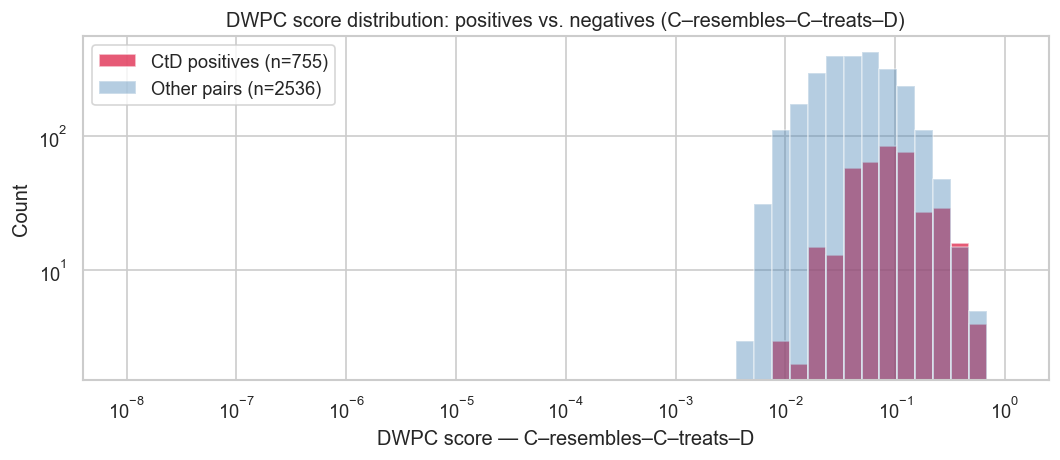

In [13]:
# Visualise DWPC vs raw count score separation for the best metapath
best_mp   = auprc_df.loc[auprc_df['AUPRC_DWPC'].idxmax(), 'metapath']
e1k, e2k  = mp_keys[best_mp]
best_scores = dwpc_length2(e1k, e2k, compound_ids, disease_ids)

pos_scores = [best_scores.get(p, 0.0) for p in ctd_pairs]
neg_scores = [v for p, v in best_scores.items() if p not in ctd_pairs]

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(-8, 0, 50)
ax.hist([s for s in pos_scores if s > 0], bins=bins, alpha=0.7,
        color='crimson', label=f'CtD positives (n={len(pos_scores)})')
ax.hist([s for s in neg_scores if s > 0], bins=bins, alpha=0.4,
        color='steelblue', label=f'Other pairs (n={len(neg_scores)})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(f'DWPC score — {best_mp}')
ax.set_ylabel('Count')
ax.set_title(f'DWPC score distribution: positives vs. negatives ({best_mp})')
ax.legend()
plt.tight_layout()
plt.show()

---

## Step 9 · Open-World Assumption & Negative-Sampling Design

**The core modelling risk**: 75% of compounds have zero CtD edges, but many are pharmacologically active (they bind genes). Treating them all as 'known negatives' violates the open-world assumption (OWA) and contaminates training.

We also show that **random** negative sampling is biased toward low-degree pairs, producing negatives that are trivially easy to distinguish from positives.

=== Compounds without any CtD edge ===
  Total                       : 1,165  (75.1% of all compounds)
  Have CbG edges (active, OWA): 1,007  (86.4%)
  No CbG edges   (data-sparse): 158  (13.6%)

OWA implication: the 1007 pharmacologically active compounds with no known treatment
are likely *unstudied* rather than *inactive* — use soft negatives or exclude.


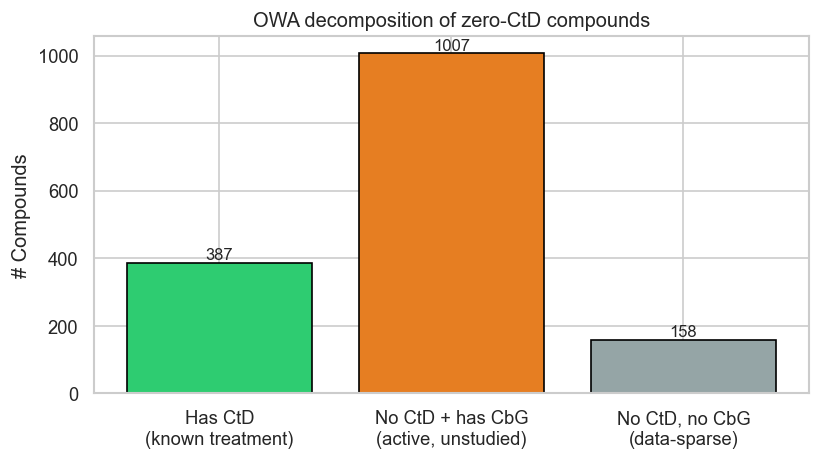

In [14]:
# ── Open-World Assumption (OWA) analysis ──────────────────────────────
has_ctd = set(compound_treats.keys())
no_ctd  = compound_ids - has_ctd

# CbG edges collected earlier as cg_edges
has_cbg = set(cg_edges.keys())

no_ctd_active   = no_ctd & has_cbg          # pharmacologically active, no known treatment
no_ctd_inactive = no_ctd - has_cbg           # no known targets either → data-sparse / inactive

print('=== Compounds without any CtD edge ===')
print(f'  Total                       : {len(no_ctd):,}  ({len(no_ctd)/len(compound_ids):.1%} of all compounds)')
print(f'  Have CbG edges (active, OWA): {len(no_ctd_active):,}  ({len(no_ctd_active)/len(no_ctd):.1%})')
print(f'  No CbG edges   (data-sparse): {len(no_ctd_inactive):,}  ({len(no_ctd_inactive)/len(no_ctd):.1%})')
print()
print('OWA implication: the', len(no_ctd_active),
      'pharmacologically active compounds with no known treatment')
print('are likely *unstudied* rather than *inactive* — use soft negatives or exclude.')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
labels  = ['Has CtD\n(known treatment)', 'No CtD + has CbG\n(active, unstudied)', 'No CtD, no CbG\n(data-sparse)']
values  = [len(has_ctd), len(no_ctd_active), len(no_ctd_inactive)]
colors  = ['#2ecc71', '#e67e22', '#95a5a6']
ax.bar(labels, values, color=colors, edgecolor='black')
for i, v in enumerate(values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=10)
ax.set_ylabel('# Compounds')
ax.set_title('OWA decomposition of zero-CtD compounds')
plt.tight_layout()
plt.show()

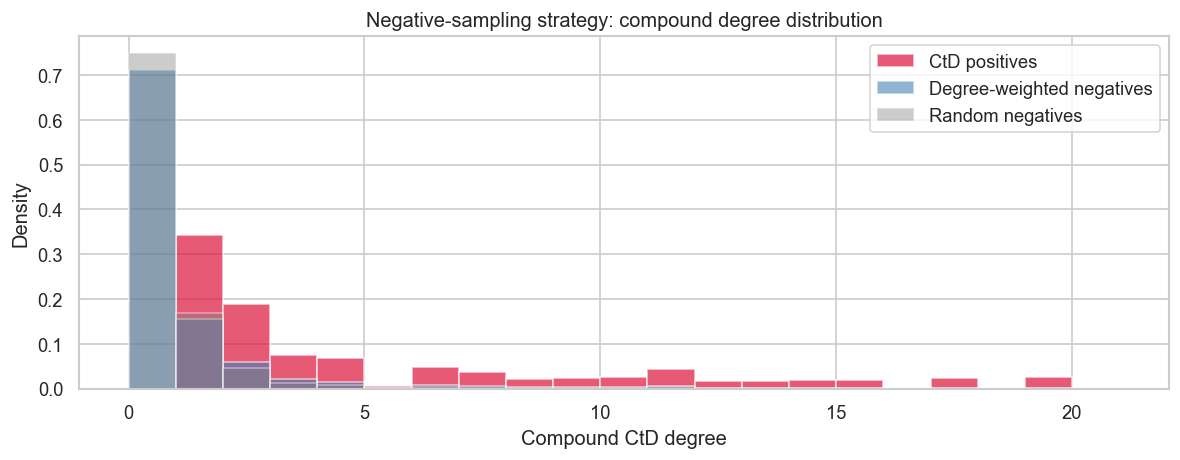

Random negatives are dominated by degree-0 compounds (easy negatives).
Degree-weighted negatives better match the positive degree distribution,
producing harder, more informative training signal.


In [15]:
# ── Negative-sampling strategy comparison ─────────────────────────────
import numpy as np

# All (C, D) pairs not in CtD — the negative pool
neg_pool = [(c, d) for c in compound_ids for d in disease_ids if (c, d) not in ctd_pairs]

# Degree under CtD graph (default to 1 for unconnected nodes)
c_deg = {c: len(ds) for c, ds in compound_treats.items()}
d_deg = {d: len(cs) for d, cs in disease_treated_by.items()}

# Degree-weighted sampling weights: sqrt(deg_c * deg_d) — mirrors positive distribution
weights = np.array([np.sqrt(c_deg.get(c, 1) * d_deg.get(d, 1)) for c, d in neg_pool],
                   dtype=np.float64)
weights /= weights.sum()

N_SAMPLE = len(ctd_pairs) * 10  # 10:1 negative ratio
rng_ns   = np.random.default_rng(42)

rand_idx   = rng_ns.choice(len(neg_pool), size=N_SAMPLE, replace=False)
degree_idx = rng_ns.choice(len(neg_pool), size=N_SAMPLE, replace=False, p=weights)

rand_c_deg   = [c_deg.get(neg_pool[i][0], 0) for i in rand_idx]
degree_c_deg = [c_deg.get(neg_pool[i][0], 0) for i in degree_idx]
pos_c_deg    = [c_deg.get(c, 0) for c, _ in ctd_pairs]

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, 22)
ax.hist(pos_c_deg,    bins=bins, alpha=0.7, density=True,
        color='crimson',   label='CtD positives')
ax.hist(degree_c_deg, bins=bins, alpha=0.6, density=True,
        color='steelblue', label='Degree-weighted negatives')
ax.hist(rand_c_deg,   bins=bins, alpha=0.4, density=True,
        color='grey',      label='Random negatives')
ax.set_xlabel('Compound CtD degree')
ax.set_ylabel('Density')
ax.set_title('Negative-sampling strategy: compound degree distribution')
ax.legend()
plt.tight_layout()
plt.show()

print('Random negatives are dominated by degree-0 compounds (easy negatives).')
print('Degree-weighted negatives better match the positive degree distribution,')
print('producing harder, more informative training signal.')